In [15]:
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.checkpoint.memory import Checkpoint, MemorySaver
from langgraph.types import interrupt, Command
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage, AnyMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [16]:
load_dotenv()

True

In [17]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.7
)

In [18]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


In [19]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type":"approval",
        "reason":"Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question?, yes/no"
    })

    if decision["approved"] == "no":
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state['messages'])
        return {"messages":[response]}

In [20]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START,"chat")
builder.add_edge("chat", END)

checkpointer = MemorySaver()

app = builder.compile(checkpointer=checkpointer)

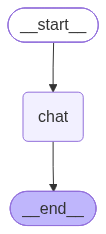

In [21]:
app

In [22]:
config = {"configurable":{"thread_id": "test--001"}}    # create new thread

""" step 1:- user asks question"""
initial_input = {
    "messages":[
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

result = app.invoke(initial_input, config=config)

In [23]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='a456d50f-985d-45dc-84da-77cc2094d603')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question?, yes/no'}, id='5d4731f1e6b4fd0085bd0f960e13c268')]}

In [24]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question?, yes/no'}

In [25]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (yes/no):").strip().lower()

In [26]:
# resume the graph with approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config
)

In [27]:
print(final_result["messages"][-1].content)

Not approved.
